# Titanic Survival Prediction
## Professional Machine Learning Classification Project

This notebook predicts passenger survival using a clean, reproducible machine-learning workflow. It prevents data leakage with reusable preprocessing pipelines, compares models using five-fold stratified cross-validation, tunes a Random Forest, selects the final model **using cross-validation only**, and evaluates that one selected model on the untouched test set.

**Workflow:** Load Data → Data Quality Assessment → Survival-Focused EDA → Feature Engineering → Train-Test Split → Preprocessing Pipeline → Cross-Validation → Hyperparameter Tuning → CV-Based Final Model Selection → Fit on Full Training Set → One Final Test Evaluation → Prediction and Model Saving

# 1. Project Overview and Objective

### Objective
Build a reliable binary-classification workflow that predicts whether a Titanic passenger survived.

### Main improvements
- Load and inspect the dataset only once.
- Keep categorical values readable and process them inside a pipeline.
- Split the data before fitting imputers, encoders, or scalers.
- Compare Logistic Regression, Decision Tree, and Random Forest using five-fold cross-validation.
- Tune Random Forest using `GridSearchCV` on the training data only.
- Select the final model using mean cross-validation F1-score, not test-set performance.
- Evaluate the selected model once on the untouched test set.
- Save the complete preprocessing-and-model pipeline for reuse.

# 2. Import Libraries

In [1]:
from pathlib import Path

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", None)

# 3. Load Dataset

In [2]:
DATA_FILENAME = "Titanic-Dataset.csv"
candidate_paths = [
    Path(DATA_FILENAME),
    Path.cwd() / DATA_FILENAME,
    Path.cwd().parent / DATA_FILENAME,
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        f"{DATA_FILENAME} was not found. Place it in the same folder as the notebook, "
        "then restart the kernel and run all cells."
    )

df = pd.read_csv(DATA_PATH)
print("Dataset path:", DATA_PATH.resolve())
print("Dataset shape:", df.shape)
display(df.head())

Dataset path: C:\Users\layan\Downloads\archive (2)\archive (1)\Titanic-Dataset.csv
Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 4. Data Quality Assessment

In [3]:
print("Dataset information:\n")
df.info()

print("\nMissing values by column:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values"))

print("Duplicated rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Dataset information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values by column:


,Missing Values
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


Duplicated rows: 0

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


### Data-quality observations
- `Age`, `Cabin`, and `Embarked` contain missing values.
- `Cabin` has a very high missing-value rate, so it is not used as a model feature.
- Missing values in selected features are handled **inside the preprocessing pipeline**, preventing leakage from the test set.

# 5. Exploratory Data Analysis

## 5.1 Survival Rate by Gender

Sex
female    74.2%
male      18.9%
Name: Survived, dtype: object


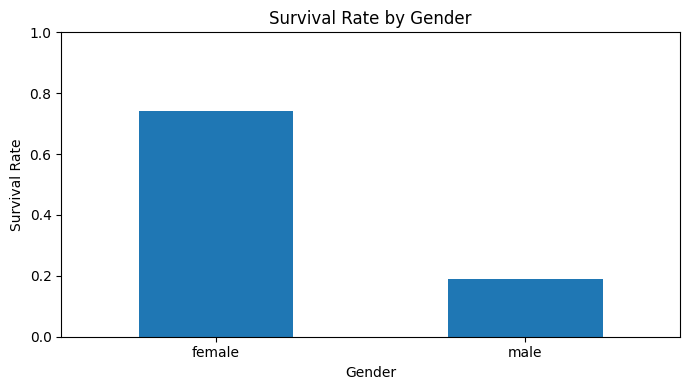

In [4]:
survival_by_sex = df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
print((survival_by_sex * 100).round(1).astype(str) + "%")

survival_by_sex.plot(kind="bar", figsize=(7, 4))
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.xlabel("Gender")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** Female passengers had a much higher survival rate (about 74%) than male passengers (about 19%). Gender is therefore strongly associated with survival in this dataset.

## 5.2 Survival Rate by Passenger Class

Pclass
1    63.0%
2    47.3%
3    24.2%
Name: Survived, dtype: object


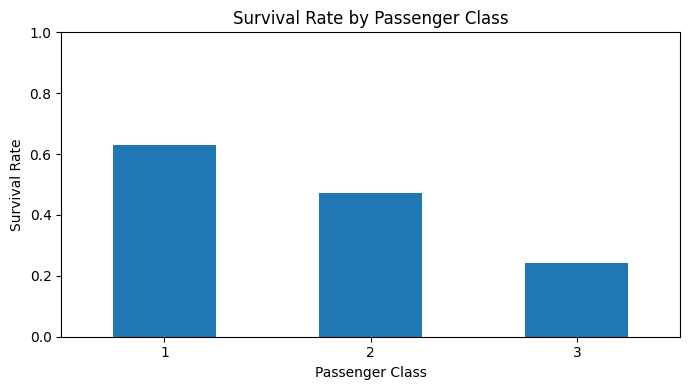

In [5]:
survival_by_class = df.groupby("Pclass")["Survived"].mean().sort_index()
print((survival_by_class * 100).round(1).astype(str) + "%")

survival_by_class.plot(kind="bar", figsize=(7, 4))
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** First-class passengers had the highest survival rate, while third-class passengers had the lowest. Passenger class appears to capture important differences in access, location, and evacuation opportunity.

## 5.3 Survival Rate by Embarkation Port

Embarked
C    55.4%
Q    39.0%
S    33.7%
Name: Survived, dtype: object


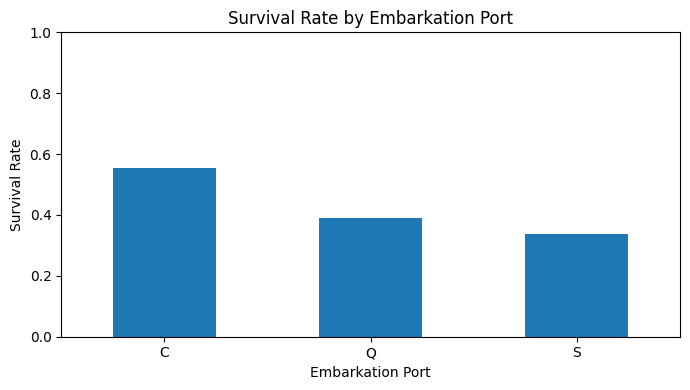

In [6]:
survival_by_embarked = df.groupby("Embarked")["Survived"].mean().sort_values(ascending=False)
print((survival_by_embarked * 100).round(1).astype(str) + "%")

survival_by_embarked.plot(kind="bar", figsize=(7, 4))
plt.title("Survival Rate by Embarkation Port")
plt.ylabel("Survival Rate")
plt.xlabel("Embarkation Port")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** Passengers who embarked at Cherbourg (`C`) had the highest survival rate. This relationship may partly reflect differences in passenger class and fare rather than the port alone.

## 5.4 Age Distribution by Survival

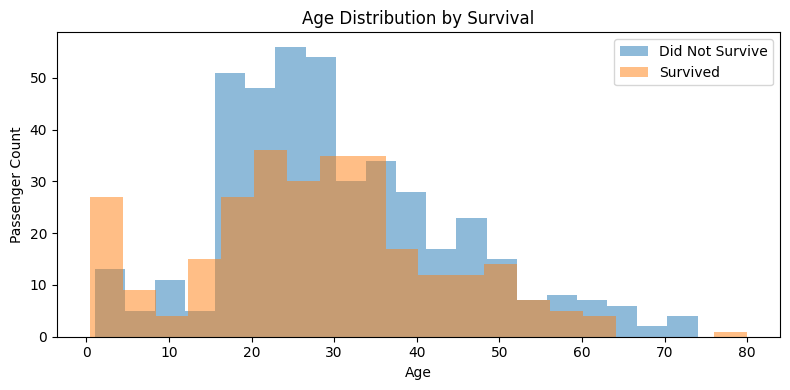

In [7]:
df.loc[df["Survived"] == 0, "Age"].plot(
    kind="hist", bins=20, alpha=0.5, figsize=(8, 4), label="Did Not Survive"
)
df.loc[df["Survived"] == 1, "Age"].plot(
    kind="hist", bins=20, alpha=0.5, label="Survived"
)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Passenger Count")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The two age distributions overlap substantially, so age alone cannot explain survival. However, younger children appear more represented among survivors than among non-survivors.

# 6. Feature Engineering

In [8]:
# Family-related features
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Extract a passenger title from Name, then combine uncommon titles into "Rare"
df["Title"] = (
    df["Name"]
    .str.extract(r",\s*([^.]*)\.", expand=False)
    .str.strip()
    .replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
)

common_titles = ["Mr", "Miss", "Mrs", "Master"]
df["Title"] = df["Title"].where(df["Title"].isin(common_titles), "Rare")

display(df[["Name", "FamilySize", "IsAlone", "Title"]].head())
print("\nTitle counts:")
display(df["Title"].value_counts().to_frame("Count"))

,Name,FamilySize,IsAlone,Title
0,"Braund, Mr. Owen Harris",2,0,Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,0,Mrs
2,"Heikkinen, Miss. Laina",1,1,Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2,0,Mrs
4,"Allen, Mr. William Henry",1,1,Mr



Title counts:


,Count
Title,
Mr,517
Miss,185
Mrs,126
Master,40
Rare,23


`FamilySize` combines parents, children, siblings, and spouses into one interpretable measure. `IsAlone` identifies passengers traveling without family, while `Title` summarizes social and demographic information contained in the passenger name.

# 7. Define Features and Target

In [9]:
base_feature_columns = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
]

title_feature_columns = base_feature_columns + ["Title"]
y = df["Survived"]

print("Base feature count:", len(base_feature_columns))
print("Feature count with Title:", len(title_feature_columns))
print("Target shape:", y.shape)

Base feature count: 9
Feature count with Title: 10
Target shape: (891,)


# 8. Train-Test Split

In [10]:
train_indices, test_indices = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

print("Training rows:", len(train_indices))
print("Testing rows:", len(test_indices))
print("Training survival rate:", f"{y_train.mean():.2%}")
print("Testing survival rate:", f"{y_test.mean():.2%}")

Training rows: 712
Testing rows: 179
Training survival rate: 38.34%
Testing survival rate: 38.55%


Using `stratify=y` preserves a similar survived/non-survived proportion in the training and testing sets. No imputer, encoder, or scaler is fitted before this split.

# 9. Preprocessing Pipeline

In [11]:
def build_preprocessor(feature_columns):
    """Create separate preprocessing pipelines for numerical and categorical features."""
    categorical_candidates = ["Sex", "Embarked", "Title"]
    categorical_features = [
        column for column in categorical_candidates if column in feature_columns
    ]
    numerical_features = [
        column for column in feature_columns if column not in categorical_features
    ]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features),
    ])


def build_model_pipeline(model, feature_columns):
    """Keep preprocessing and model training together in one reusable pipeline."""
    return Pipeline([
        ("preprocessor", build_preprocessor(feature_columns)),
        ("model", model),
    ])

The pipeline prevents data leakage because the median, most-frequent category, scaling values, and one-hot categories are learned only from each training fold or from the final training set.

# 10. Compare Performance Before and After Adding Title

In [12]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
feature_experiment_results = []

for experiment_name, feature_columns in {
    "Without Title": base_feature_columns,
    "With Title": title_feature_columns,
}.items():
    experiment_X_train = df.loc[train_indices, feature_columns]
    experiment_pipeline = build_model_pipeline(
        LogisticRegression(max_iter=1000, random_state=42),
        feature_columns,
    )
    experiment_scores = cross_val_score(
        experiment_pipeline,
        experiment_X_train,
        y_train,
        cv=cv_strategy,
        scoring="f1",
        n_jobs=1,
    )
    feature_experiment_results.append({
        "Feature Set": experiment_name,
        "Mean CV F1": experiment_scores.mean(),
        "CV Standard Deviation": experiment_scores.std(),
    })

feature_experiment_df = pd.DataFrame(feature_experiment_results)
display(feature_experiment_df.sort_values("Mean CV F1", ascending=False))

use_title = (
    feature_experiment_df.loc[
        feature_experiment_df["Feature Set"] == "With Title", "Mean CV F1"
    ].iloc[0]
    >= feature_experiment_df.loc[
        feature_experiment_df["Feature Set"] == "Without Title", "Mean CV F1"
    ].iloc[0]
)

feature_columns = title_feature_columns if use_title else base_feature_columns
X_train = df.loc[train_indices, feature_columns]
X_test = df.loc[test_indices, feature_columns]

print("Selected feature set:", "With Title" if use_title else "Without Title")
print("Final features:", feature_columns)

,Feature Set,Mean CV F1,CV Standard Deviation
1,With Title,0.761008,0.027274
0,Without Title,0.729435,0.016930


Selected feature set: With Title
Final features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']


**Interpretation:** Adding `Title` increases the mean cross-validation F1-score, so it is retained in the final feature set. The decision is based only on training-set cross-validation, not on test-set performance.

# 11. Model Creation

In [13]:
models = {
    "Logistic Regression": build_model_pipeline(
        LogisticRegression(max_iter=1000, random_state=42),
        feature_columns,
    ),
    "Decision Tree": build_model_pipeline(
        DecisionTreeClassifier(
            max_depth=5,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
        ),
        feature_columns,
    ),
    "Random Forest": build_model_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=1,
        ),
        feature_columns,
    ),
}

print("Models created:", list(models.keys()))

Models created: ['Logistic Regression', 'Decision Tree', 'Random Forest']


# 12. Cross-Validation

In [14]:
cv_results = []

for model_name, model_pipeline in models.items():
    scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring="f1",
        n_jobs=1,
    )
    cv_results.append({
        "Model": model_name,
        "Mean CV F1": scores.mean(),
        "CV Standard Deviation": scores.std(),
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("Mean CV F1", ascending=False)
    .reset_index(drop=True)
)
display(cv_results_df)

best_baseline_model_name = cv_results_df.iloc[0]["Model"]
print("Best baseline model by mean CV F1:", best_baseline_model_name)

,Model,Mean CV F1,CV Standard Deviation
0,Logistic Regression,0.761008,0.027274
1,Random Forest,0.737307,0.028074
2,Decision Tree,0.728175,0.020615


Best baseline model by mean CV F1: Logistic Regression


**Interpretation:** Logistic Regression has the strongest average baseline F1-score. The standard deviations are relatively small, indicating that performance is reasonably stable across the five folds. Cross-validation is more reliable than one split because every training observation is used for both training and validation across different folds.

# 13. Hyperparameter Tuning

The Random Forest is tuned using only the training data. `GridSearchCV` controls CPU parallelism, while the estimator itself uses one worker to avoid nested parallel processing.

In [15]:
parameter_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 8],
    "model__min_samples_split": [10],
    "model__min_samples_leaf": [1],
}

forest_tuning_pipeline = build_model_pipeline(
    RandomForestClassifier(random_state=42, n_jobs=1),
    feature_columns,
)

grid_search = GridSearchCV(
    estimator=forest_tuning_pipeline,
    param_grid=parameter_grid,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True,
)

# Threading avoids process-spawn overhead while GridSearchCV still controls parallelism.
with joblib.parallel_backend("threading"):
    grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print(f"Best tuned Random Forest CV F1: {grid_search.best_score_:.4f}")

Best parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Best tuned Random Forest CV F1: 0.7699


The search is completed before the test set is used. This keeps hyperparameter tuning separate from final evaluation.

# 14. Select the Final Model Using Cross-Validation

The final model is selected by the highest mean cross-validation F1-score. Test-set results are not included in this decision.

In [16]:
logistic_cv_f1 = cv_results_df.loc[
    cv_results_df["Model"] == "Logistic Regression",
    "Mean CV F1",
].iloc[0]

tuned_forest_cv_f1 = grid_search.best_score_

final_cv_comparison = pd.DataFrame([
    {"Model": "Logistic Regression", "Mean CV F1": logistic_cv_f1},
    {"Model": "Tuned Random Forest", "Mean CV F1": tuned_forest_cv_f1},
])

final_cv_comparison = (
    final_cv_comparison
    .sort_values("Mean CV F1", ascending=False)
    .reset_index(drop=True)
)

display(final_cv_comparison)

best_cv_row = final_cv_comparison.iloc[0]
final_model_name = best_cv_row["Model"]

if final_model_name == "Logistic Regression":
    final_model = models["Logistic Regression"]
else:
    final_model = grid_search.best_estimator_

print("Selected using cross-validation:", final_model_name)
print(f"Selected mean CV F1: {best_cv_row['Mean CV F1']:.4f}")

,Model,Mean CV F1
0,Tuned Random Forest,0.769925
1,Logistic Regression,0.761008


Selected using cross-validation: Tuned Random Forest
Selected mean CV F1: 0.7699


**Selection rule:** choose the model with the highest mean five-fold cross-validation F1-score. The rule is defined before the test set is examined.

# 15. Fit the Selected Model on the Full Training Set

In [17]:
final_model.fit(X_train, y_train)
print(f"{final_model_name} fitted on all training rows: {len(X_train)}")

Tuned Random Forest fitted on all training rows: 712


The model is now fixed. The test set has remained untouched throughout feature comparison, baseline comparison, and hyperparameter tuning.

# 16. Evaluate the Untouched Test Set Once

Only the selected final model is evaluated. Its predictions are reused for the confusion matrix and overfitting check.

In [18]:
final_predictions = final_model.predict(X_test)
final_probabilities = final_model.predict_proba(X_test)[:, 1]

final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(y_test, final_predictions, zero_division=0)
final_recall = recall_score(y_test, final_predictions, zero_division=0)
final_f1 = f1_score(y_test, final_predictions, zero_division=0)
final_roc_auc = roc_auc_score(y_test, final_probabilities)

final_test_results = pd.DataFrame([{
    "Final Model": final_model_name,
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1 Score": final_f1,
    "ROC-AUC": final_roc_auc,
}])

display(final_test_results)
print("Classification Report:")
print(classification_report(y_test, final_predictions, digits=3))

,Final Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Random Forest,0.832402,0.809524,0.73913,0.772727,0.853228


Classification Report:
              precision    recall  f1-score   support

           0      0.845     0.891     0.867       110
           1      0.810     0.739     0.773        69

    accuracy                          0.832       179
   macro avg      0.827     0.815     0.820       179
weighted avg      0.831     0.832     0.831       179



The test metrics describe the selected model only. They are reported after model selection and are not used to choose between models.

## 16.1 Confusion Matrix of the Final Model

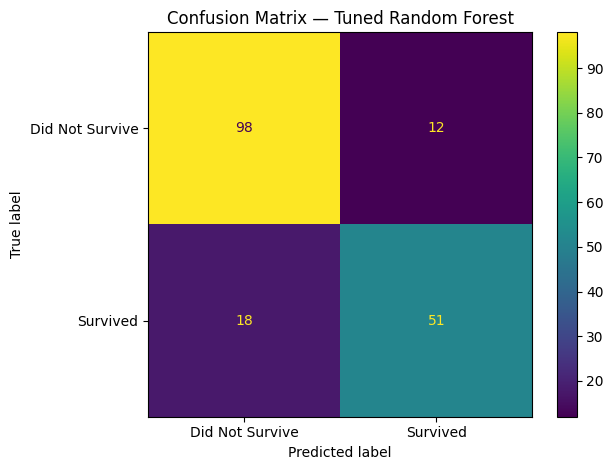

True Negatives:  98
False Positives: 12
False Negatives: 18
True Positives:  51


In [19]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    display_labels=["Did Not Survive", "Survived"],
)
plt.title(f"Confusion Matrix — {final_model_name}")
plt.tight_layout()
plt.show()

final_cm = confusion_matrix(y_test, final_predictions)
tn, fp, fn, tp = final_cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

**Interpretation:** True negatives and true positives are correct predictions. False positives are passengers incorrectly predicted to survive, while false negatives are survivors incorrectly predicted not to survive.

## 16.2 Overfitting Check

In [20]:
train_predictions = final_model.predict(X_train)
train_f1 = f1_score(y_train, train_predictions, zero_division=0)
test_f1 = final_f1
absolute_f1_gap = abs(train_f1 - test_f1)

print(f"Final model: {final_model_name}")
print(f"Training F1: {train_f1:.4f}")
print(f"Testing F1:  {test_f1:.4f}")
print(f"Absolute F1 gap: {absolute_f1_gap:.4f}")

if train_f1 > test_f1:
    direction = "Training F1 is higher than testing F1."
else:
    direction = "Testing F1 is higher than training F1."

if absolute_f1_gap < 0.05:
    interpretation = (
        "The gap is small and does not provide strong evidence of overfitting. "
        "Normal sampling variation can explain a slightly higher score on either split."
    )
else:
    interpretation = (
        "The gap is noticeable. Cross-validation remains the more reliable estimate "
        "of expected generalization, and model complexity may need review."
    )

print(direction)
print(interpretation)

Final model: Tuned Random Forest
Training F1: 0.7808
Testing F1:  0.7727
Absolute F1 gap: 0.0080
Training F1 is higher than testing F1.
The gap is small and does not provide strong evidence of overfitting. Normal sampling variation can explain a slightly higher score on either split.


The absolute gap measures the size of the training–testing difference, while the printed direction explains which score is higher. Cross-validation remains the primary estimate of generalization.

# 17. New Passenger Prediction

In [21]:
new_passenger = pd.DataFrame([{
    "Pclass": 3,
    "Sex": "male",
    "Age": 25,
    "SibSp": 0,
    "Parch": 0,
    "Fare": 8.05,
    "Embarked": "S",
    "FamilySize": 1,
    "IsAlone": 1,
    "Title": "Mr",
}])

new_passenger = new_passenger[feature_columns]
prediction = final_model.predict(new_passenger)[0]
probability = final_model.predict_proba(new_passenger)[0, 1]
prediction_label = "Survived" if prediction == 1 else "Did Not Survive"

print("Final model used:", final_model_name)
print("Prediction:", prediction_label)
print(f"Survival Probability: {probability:.2%}")

Final model used: Tuned Random Forest
Prediction: Did Not Survive
Survival Probability: 11.36%


The prediction uses human-readable values such as `male`, `S`, and `Mr`. The complete pipeline automatically handles imputation, scaling, and encoding.

# 18. Save the Final Pipeline

In [22]:
MODEL_PATH = Path("titanic_survival_pipeline.joblib")
joblib.dump(final_model, MODEL_PATH)

loaded_model = joblib.load(MODEL_PATH)
loaded_prediction = loaded_model.predict(new_passenger)[0]

print("Saved final model:", final_model_name)
print("Saved path:", MODEL_PATH.resolve())
print("Loaded-model prediction matches:", loaded_prediction == prediction)

Saved final model: Tuned Random Forest
Saved path: C:\Users\layan\Downloads\archive (2)\archive (1)\titanic_survival_pipeline.joblib
Loaded-model prediction matches: True


# 19. Environment Requirements

A matching `requirements.txt` file is included with the project.

```text
pandas>=2.0
matplotlib>=3.7
scikit-learn>=1.2
joblib>=1.3
notebook>=7.0
```

Recommended project files:

```text
Titanic_Project_Final_Corrected.ipynb
Titanic-Dataset.csv
titanic_survival_pipeline.joblib
README.md
requirements.txt
```

# 20. Conclusion and Limitations

The final model was selected using five-fold stratified cross-validation on the training data, so the test set remained untouched until model selection was complete. The **Tuned Random Forest** achieved the highest mean cross-validation F1-score (**0.7699**) compared with Logistic Regression (**0.7610**) and was therefore selected as the final model.

After fitting the selected pipeline on the complete training set, it was evaluated once on the untouched test set. It achieved approximately **83.24% Accuracy**, **0.8095 Precision**, **0.7391 Recall**, **0.7727 F1-score**, and **0.8532 ROC-AUC**. The absolute training–testing F1 gap was only **0.0080**, which does not provide strong evidence of overfitting.

The preprocessing pipeline handles missing values, numerical scaling, and categorical one-hot encoding without data leakage. The exploratory analysis and engineered features indicate that gender, passenger class, age, embarkation port, family-related variables, and passenger title contain useful survival information.

### Limitations
- The dataset is small and represents one historical event.
- Several original fields contain missing data, especially `Cabin`.
- Relationships are observational and should not be interpreted as causal.
- Performance may vary with another sample or validation strategy.

### Future work
Possible extensions include permutation feature importance, SHAP explanations, a Streamlit prediction interface, probability calibration, fairness analysis, and automated tests for feature engineering.

# Final Readiness Checklist

- Dataset loaded once: **Complete**
- Duplicate code removed: **Complete**
- Survival-focused EDA and written interpretations: **Complete**
- Feature engineering documented: **Complete**
- Stratified split and leakage-safe pipelines: **Complete**
- Three baseline models compared with five-fold CV: **Complete**
- Random Forest tuned with `GridSearchCV`: **Complete**
- Final model selected using CV only: **Complete**
- Test set evaluated after selection: **Complete**
- Global warning suppression removed: **Complete**
- Nested parallelism corrected: **Complete**
- Absolute training–testing F1 gap interpreted: **Complete**
- Final pipeline saved: **Complete**
- Environment requirements added: **Complete**
- Conclusion updated: **Complete**